In [1]:
from pathlib import Path
import numpy as np
from ovito.io import import_file
from ovito.data import DataCollection
from ovito.modifiers import ExpressionSelectionModifier, DeleteSelectedModifier, InvertSelectionModifier, AssignColorModifier
from ovito.pipeline import FileSource, Pipeline
from ovito.vis import Viewport, CoordinateTripodOverlay, ParticlesVis, SurfaceMeshVis, TextLabelOverlay, PythonViewportOverlay, ViewportOverlayInterface
from ovito.qt_compat import QtCore

input_path = Path("/home/Ethan/Projects/prec_interactions/data/shear_T800_SR1E7_R40_N8562")

In [2]:
import numpy as np

# 1. Load Pipelines
dxa_pipeline = import_file(input_path / "dxa_raw" / "dxa_*.ca")
atoms_pipeline = import_file(input_path / "dxa_atoms" / "dxa_atoms_*.dump")

# 2. Calculate Simulation Box Center
data = atoms_pipeline.compute(0)
cell = data.cell
# Box Center = 0.5 * (A + B + C) + Origin
box_center = 0.5 * (cell[:,0] + cell[:,1] + cell[:,2]) + cell[:,3]

# 3. Process atoms to show precipitate (Type 4)
atoms_pipeline.modifiers.append(ExpressionSelectionModifier(expression="ParticleType != 4"))
atoms_pipeline.modifiers.append(DeleteSelectedModifier())
atoms_pipeline.modifiers.append(InvertSelectionModifier())
atoms_pipeline.modifiers.append(AssignColorModifier(color=(1.0, 0.84, 0.0)))

# 4. Scene Setup
dxa_pipeline.add_to_scene()
atoms_pipeline.add_to_scene()

for vis_element in dxa_pipeline.vis_elements:
    if isinstance(vis_element, SurfaceMeshVis):
        vis_element.enabled = False

cell_vis = dxa_pipeline.source.data.cell.vis
cell_vis.line_width = 0.2
cell_vis.rendering_color = (1.0, 1.0, 1.0)

# 5. Camera Configuration (Y-UP and Centered)
vp = Viewport()
vp.type = Viewport.Type.Perspective

# Tweak these to change your "off-diagonal" angle
# This vector represents where the camera is relative to the center
view_vector = np.array([-1.2, 1.0, 1.5]) 
view_vector /= np.linalg.norm(view_vector) # Normalize

distance = 1000.0 

# Position and Direction
vp.camera_pos = box_center + (view_vector * distance)
vp.camera_dir = -view_vector 

# FORCE Y-UP DIRECTION
vp.camera_up = (0, 1, 0)

# 6. Overlays
# Coordinate Tripod
tripod = CoordinateTripodOverlay(size=0.07, alignment=QtCore.Qt.AlignmentFlag.AlignLeft | QtCore.Qt.AlignmentFlag.AlignBottom)
vp.overlays.append(tripod)

# File Title
vp.overlays.append(TextLabelOverlay(
    text=f'{input_path.name}',
    alignment=QtCore.Qt.AlignmentFlag.AlignHCenter | QtCore.Qt.AlignmentFlag.AlignTop,
    font_size=0.02,
    text_color=(1,1,1)
))

# Dynamic Timestep Overlay
class CoordinationPlotOverlay(ViewportOverlayInterface):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def render(self, canvas, data, frame, **kwargs):
        self.pipeline.compute(frame) 
        # Positioned at bottom right
        canvas.draw_text(f"Timestep: {frame*1000}", pos=(0.75, 0.05), font_size=0.02, color=(1,1,1))

vp.overlays.append(PythonViewportOverlay(delegate=CoordinationPlotOverlay(dxa_pipeline)))

# 7. Animation Export Prep
output_path = input_path / "vis" / "animation.mp4"
output_path.parent.mkdir(parents=True, exist_ok=True)

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


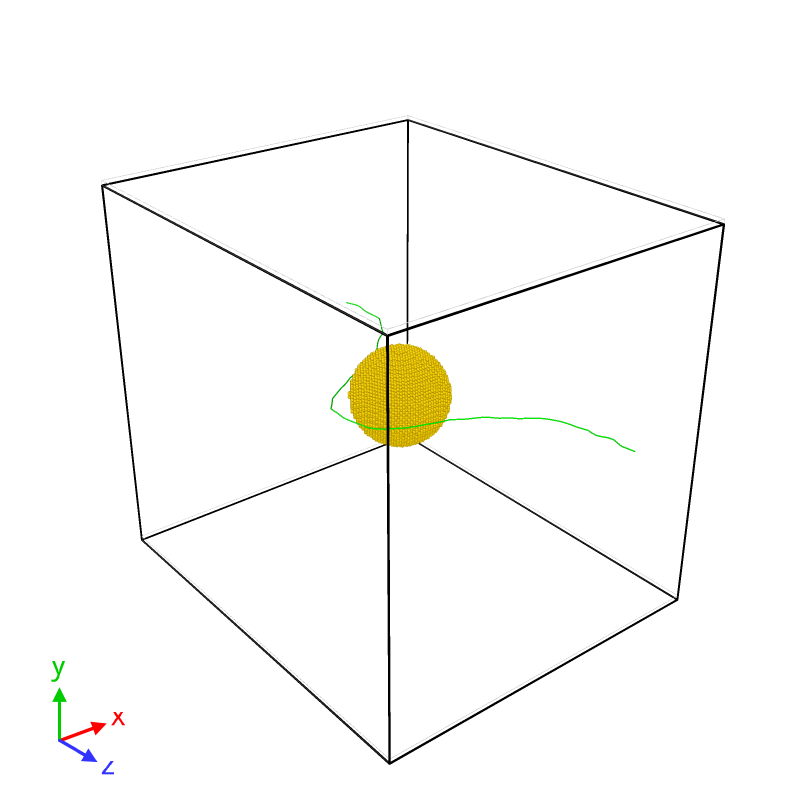

In [3]:
vp.render_image(size=(800,800), background=(1,1,1), frame=1001)

In [4]:
# Convert Path object to string and remove the invalid argument
vp.render_anim(
    size=(800, 600),
    background=(1.0, 1.0, 1.0), # White background for your gold atoms
    filename=str(output_path),
    fps=20
)

# Clean up the scene
dxa_pipeline.remove_from_scene()
atoms_pipeline.remove_from_scene()